### Notebook imports and set-up

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set()
warnings.filterwarnings('ignore')

from dslab import distribution

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Loading and initialising the data

In [101]:
# Read the training data into a DataFrame called df
df = pd.read_csv("data\\train.csv",
                 index_col=0, 
                 na_values="NaN", 
                 keep_default_na=False)

# Read the testing data into a DataFrame called test
test = pd.read_csv("data\\test.csv", 
                   index_col=0, 
                   na_values="NaN", 
                   keep_default_na=False)


# Contained below are some unused plots that I created and decided to remove.

# # Use the imported dslab distribution to create a visualisation
# distribution(df["SalePrice"])

# # Create a jointplot with SalePrice and LotArea
# sns.jointplot(x=np.log(df["LotArea"]), y=np.log(df["SalePrice"]))

# plot_figure("joint", "LotArea", log_all=True, hue_by="GrLivArea")

### Creating the plotting function

In [102]:
def plot_figure(type, feature, log_all=False, log_price=False, x_rotate=False, hue_by=None):
    # Create a joint plot
    if type == "joint":
        # If hue_by is specified, create a jointplot with hue
        if hue_by:
            if log_all:
                sns.jointplot(x=np.log(df[feature]), y=np.log(df["SalePrice"]), hue=df[hue_by])
            elif log_price:
                sns.jointplot(x=df[feature], y=np.log(df["SalePrice"]), hue=df[hue_by])
            else:
                sns.jointplot(x=df[feature], y=df["SalePrice"], hue=df[hue_by])

        # Otherwise, create a jointplot without hue
        else:
            if log_all:
                sns.jointplot(x=np.log(df[feature]), y=np.log(df["SalePrice"]))
            elif log_price:
                sns.jointplot(x=df[feature], y=np.log(df["SalePrice"]))
            else:
                sns.jointplot(x=df[feature], y=df["SalePrice"])
    
    # Create a distribution plot using the imported method
    elif type == "distribution":
        if log_all or log_price:
            distribution(np.log(df[feature]))
        else:
            distribution(df[feature])

    # Create a boxplot
    elif type == "boxplot":
        # Create a figure to work around plot overlap
        fig = plt.figure()

        # Create plot based on if/any logs are needed
        if log_all:
            sns.boxplot(x=np.log(df[feature]), y=np.log(df["SalePrice"]))
        elif log_price:
            sns.boxplot(x=df[feature], y=np.log(df["SalePrice"]))
        else:
            sns.boxplot(x=df[feature], y=df["SalePrice"])

        # Rotate the x-axis labels if specified
        if x_rotate:
            plt.xticks(rotation=270)

        # Show the plot
        fig.show()

### Creating a data story

#### Boxplot of sale price by neighbourhood

This graph shows us that the distribution of sale prices differs between neighbourhoods. We can see that there are some neighbourhoods with a particularly high average log sale price, such as NridgHt (Northridge Heights), NoRidge (Northridge), and StoneBr (Stone Bridge) - and there are also those with a particularly low average log sale price, such as MeadowV (Meadow Village), IDOTRR (Iowa DOT and Rail Road), and BrDale (Briardale). This suggests that we can use the feature Neighbourhood to help us predict the target variable, the sale price.

Text(0, 0.5, 'log Sale price (log $USD)')

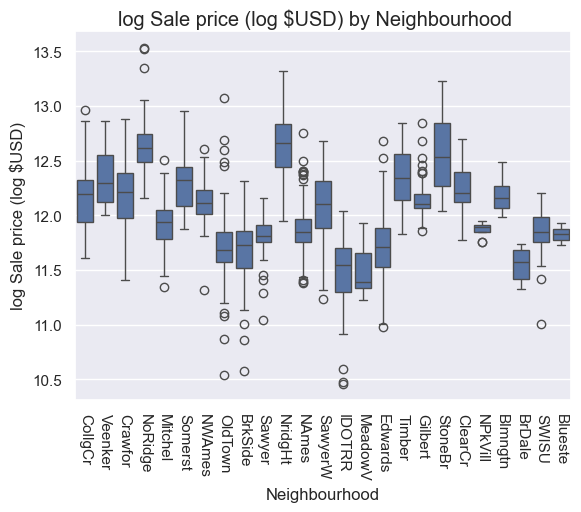

In [114]:
plot_figure("boxplot", "Neighborhood", x_rotate=True, log_price=True)
plt.suptitle("log Sale price (log $USD) by Neighbourhood", y=0.925)
plt.xlabel("Neighbourhood")
plt.ylabel("log Sale price (log $USD)")

#### Boxplot of sale price by total rooms above ground

This graph shows us that the distribution of sale prices differs depending on the total number of rooms above ground. It shows that as the number of total rooms above ground increases, the log sale price also tends to increase - which is to be expected, as more rooms means the property is likely to be worth more and therefore have a higher sale price. A plateau in the increase of sale price appears to be present for properties with 11-14 rooms, but the data in this range is very limited, so this particular observation is weak. Overall, the total number of rooms above grade could potentially be used as a predictor for the sale price of a property.

Text(0, 0.5, 'log Sale price (log $USD)')

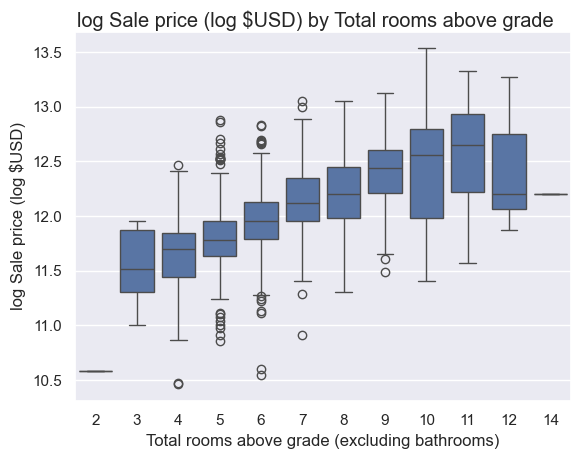

In [111]:
plot_figure("boxplot", "TotRmsAbvGrd", log_price=True)
plt.suptitle("log Sale price (log $USD) by Total rooms above grade", y=0.925)
plt.xlabel("Total rooms above grade (excluding bathrooms)")
plt.ylabel("log Sale price (log $USD)")

#### Scatterplot of sale price vs overall quality, coloured by year built

This graph shows us the distribution of the log of sale prices against overall quality. A strong, linear, positive relationship is observed, which aligns with common sense, in that a property of higher quality is likely to be sold for a higher value, as it is more appealing to buyers and is therefore worth more. The colour of the graph shows us that the properties of higher quality (and log sale price) tend to have been built more recently, whereas the properties built longer ago tend to have a lower overall quality and therefore have a lower log sale price. This indicates that the overall quality of the property and the year that it was built can be valuable features when it comes to predicting the sale price accurately.

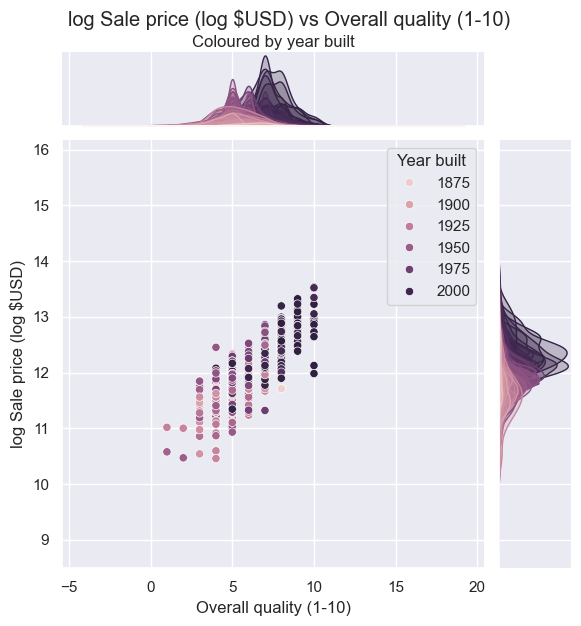

In [115]:
plot_figure("joint", "OverallQual", log_price=True, hue_by="YearBuilt")
plt.suptitle("log Sale price (log $USD) vs Overall quality (1-10)", y=1.04)
plt.title("Coloured by year built", y = 1.2)
plt.xlabel("Overall quality (1-10)")
plt.ylabel("log Sale price (log $USD)")
plt.legend(title="Year built", loc="upper right")

#### Scatterplot of sale price vs total living area above ground, coloured by total rooms above ground

This graph shows us the distribution of the log of sale prices against the log of total rooms above ground. A medium strength positive relationship is observed, which appears to be linear. This is understandable, as a property with more living area is larger and is therefore likely to be sold for a higher value than a smaller property. The hue of the graph shows us that properties with greater total living area above ground tend to have more total rooms above ground, which completely makes sense, as more rooms would sensible also increase living area. Therefore, since we wish to predict the sale price of a property, the above grade living area is likely a feture that we should take into account.

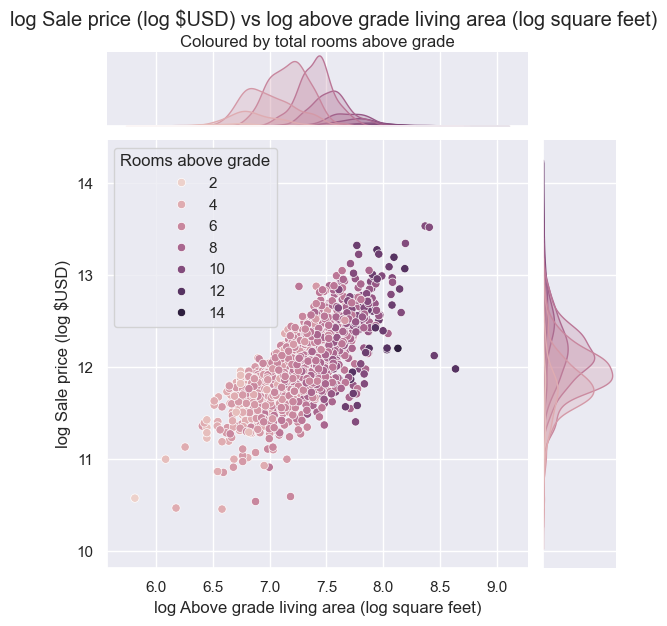

In [116]:
plot_figure("joint", "GrLivArea", log_all=True, hue_by="TotRmsAbvGrd")
plt.suptitle("log Sale price (log $USD) vs log above grade living area (log square feet)", y=1.04)
plt.title("Coloured by total rooms above grade", y = 1.2)
plt.xlabel("log Above grade living area (log square feet)")
plt.ylabel("log Sale price (log $USD)")
plt.legend(title="Rooms above grade", loc="upper left")

#### Scatterplot of sale price vs garage area, coloured by garage car capacity

This graph shows us the distribution of the log of sale prices against the log of garage area. A weak, linear, positive relationship is observed, which aligns with common sense, in that a property with a larger garage is likely to be sold for a higher value, as it can accomodate more vehicles and is therefore mre appealing to buyers. The hue of the graph also shows us that as the log garage area increases, the garage car capacity also tends to increase. These two features should therefore be included when making a prediction on the target variable for a particular property.

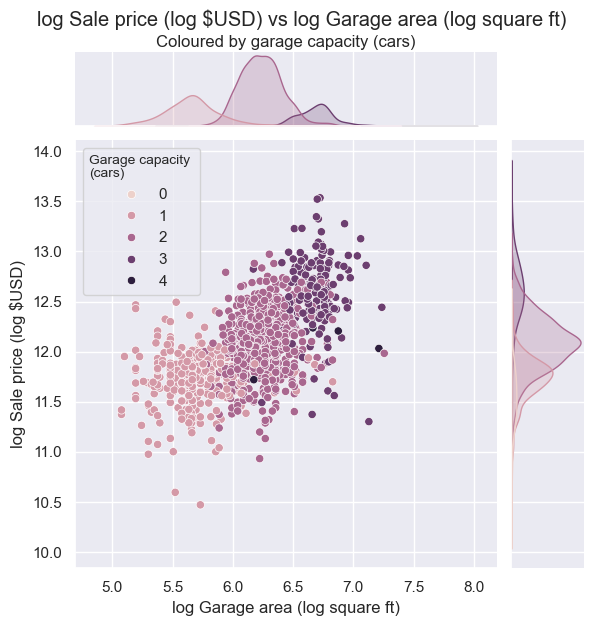

In [108]:
plot_figure("joint", "GarageArea", log_all=True, hue_by="GarageCars")
plt.suptitle("log Sale price (log $USD) vs log Garage area (log square ft)", y=1.04)
plt.title("Coloured by garage capacity (cars)", y = 1.2)
plt.xlabel("log Garage area (log square ft)")
plt.ylabel("log Sale price (log $USD)")
plt.legend(title="Garage capacity \n(cars)", loc="upper left", title_fontsize=10)

### Data story

As we can see from these 5 plots, there are several features of a property that demonstrate a relationship with the target variable, the sale price. This includes, but is not limited to: the neighbourhood, the number of total rooms above grade, the overall quality of the property and the year that it was built, above grade living area, garage area, and the car capacity of a garage. These can and should be taken into account when training the model in predicting the target. Most of these relationships are positive and linear, indicating that there seems to be a trend: as the amount of property increases (whether it be interioror exterior), the average sale price linearly increases as well.